In [1]:
import numpy as np

from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

import shap
from lime.lime_text import LimeTextExplainer


In [2]:
# Load Hugging Face model
model_name = "dslim/bert-base-NER"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

# NER pipeline with aggregation_strategy="simple"
ner_pipeline = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

# Model's coarse label space for SHAP/LIME
class_names = ["PER", "ORG", "LOC", "MISC"]
label_to_index = {label: i for i, label in enumerate(class_names)}

print("Class names for SHAP/LIME:", class_names)


Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Class names for SHAP/LIME: ['PER', 'ORG', 'LOC', 'MISC']


In [3]:
def predict_proba(texts):
    """
    Prediction wrapper around the NER pipeline for SHAP and LIME.
    
    Input:
        texts: list of raw text strings.
    
    For each text:
      - Run the NER pipeline.
      - Aggregate entity scores into a single probability vector
        over the 4 coarse classes: PER, ORG, LOC, MISC.
        (sum scores per entity_group, then normalize to sum to 1).
    
    Output:
        np.ndarray of shape (n_examples, 4).
    """
    all_probs = []

    for text in texts:
        entities = ner_pipeline(text)

        scores = np.zeros(len(class_names), dtype=float)

        for ent in entities:
            group = ent.get("entity_group", None)
            if group in label_to_index:
                scores[label_to_index[group]] += float(ent["score"])

        total = scores.sum()
        if total > 0.0:
            scores = scores / total
        else:
            # If model finds no entities, use a uniform distribution
            scores[:] = 1.0 / len(class_names)

        all_probs.append(scores)

    return np.vstack(all_probs)


# Quick smoke test
example_texts = ["Bobby Robson visisted Cologne."]
print("Wrapper output shape:", predict_proba(example_texts).shape)
print("Wrapper output probabilities:", predict_proba(example_texts))


Wrapper output shape: (1, 4)
Wrapper output probabilities: [[0.50242295 0.         0.49757705 0.        ]]


In [4]:
MASK_TOKEN = "[MASK]"

def is_entity_tag(tag_name: str) -> bool:
    """
    Decide if a BIO tag is an entity tag.
    'O' = non-entity
    Anything starting with 'B-' or 'I-' = entity.
    
    This plays the same role as gold WNUT tags in your original methodology,
    but here we define them manually for our custom sentences.
    """
    return tag_name != "O"


def mask_tokens(tokens, bio_tags, mode="entity"):
    """
    mode = 'entity'  -> mask all entity tokens, keep context
    mode = 'context' -> mask all non-entity tokens, keep entities
    
    Uses manually defined BIO tags to decide entity vs non-entity.
    """
    assert mode in ("entity", "context")
    
    new_tokens = []
    for tok, tag_name in zip(tokens, bio_tags):
        is_ent = is_entity_tag(tag_name)
        
        if mode == "entity":
            # Mask entities
            if is_ent:
                new_tokens.append(MASK_TOKEN)
            else:
                new_tokens.append(tok)
        else:  # mode == "context"
            # Mask context (non-entity)
            if is_ent:
                new_tokens.append(tok)
            else:
                new_tokens.append(MASK_TOKEN)
    
    return " ".join(new_tokens)


def detokenize(tokens):

    text = ""
    punct = {".", ",", ":", ";", "!", "?", ")", "'", "\""}
    for i, tok in enumerate(tokens):
        if i == 0:
            text += tok
        else:
            if tok in punct:
                text += tok
            elif tok == "'s":
                text += tok
            else:
                text += " " + tok
    return text


In [5]:
# Each example: tokens + BIO tags (manually chosen "gold labels")
# Tag schema:
#   O = non-entity
#   B-PER, I-PER
#   B-LOC, I-LOC
#   B-ORG, I-ORG
# Types are only used to decide entity vs non-entity for masking.

examples = []

# Example 1: clear PER + LOC
tokens_1 = ["Bobby", "Robson", "visited", "Cologne", "."]
bio_1    = ["B-PER", "I-PER", "O", "B-LOC", "O"]

examples.append({
    "name": "PER + LOC (clear)",
    "tokens": tokens_1,
    "bio_tags": bio_1
})

# Example 2: ambiguous PERSON/LOCATION
tokens_2 = ["Jordan", "went", "to", "Jordan", "."]
# Define:
#   first "Jordan" = PERSON, second "Jordan" = LOCATION
bio_2    = ["B-PER", "O", "O", "B-LOC", "O"]

examples.append({
    "name": "Ambiguous PER/LOC (Jordan)",
    "tokens": tokens_2,
    "bio_tags": bio_2
})

# Example 3: ORG/LOC ambiguity
tokens_3 = ["Apple", "opened", "an", "office", "in", "Apple", "Valley", "."]
# Define:
#   first "Apple" = ORG
#   "Apple Valley" = LOC (multi-word)
bio_3    = ["B-ORG", "O", "O", "O", "O", "B-LOC", "I-LOC", "O"]

examples.append({
    "name": "Ambiguous ORG/LOC (Apple / Apple Valley)",
    "tokens": tokens_3,
    "bio_tags": bio_3
})

print("Number of custom examples:", len(examples))
for i, ex in enumerate(examples):
    print(f"\nExample {i}:", ex["name"])
    print("Tokens:  ", ex["tokens"])
    print("BIO tags:", ex["bio_tags"])
    print("Text:   ", detokenize(ex["tokens"]))


Number of custom examples: 3

Example 0: PER + LOC (clear)
Tokens:   ['Bobby', 'Robson', 'visited', 'Cologne', '.']
BIO tags: ['B-PER', 'I-PER', 'O', 'B-LOC', 'O']
Text:    Bobby Robson visited Cologne.

Example 1: Ambiguous PER/LOC (Jordan)
Tokens:   ['Jordan', 'went', 'to', 'Jordan', '.']
BIO tags: ['B-PER', 'O', 'O', 'B-LOC', 'O']
Text:    Jordan went to Jordan.

Example 2: Ambiguous ORG/LOC (Apple / Apple Valley)
Tokens:   ['Apple', 'opened', 'an', 'office', 'in', 'Apple', 'Valley', '.']
BIO tags: ['B-ORG', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'O']
Text:    Apple opened an office in Apple Valley.


In [6]:
# Build variants for each example
for ex in examples:
    tokens = ex["tokens"]
    bio = ex["bio_tags"]
    
    original_text = detokenize(tokens)
    entity_masked_text = mask_tokens(tokens, bio, mode="entity")
    context_masked_text = mask_tokens(tokens, bio, mode="context")
    
    ex["original"] = original_text
    ex["entity_masked"] = entity_masked_text
    ex["context_masked"] = context_masked_text

# Inspect all variants
for i, ex in enumerate(examples):
    print("\n========================================")
    print(f"Example {i}: {ex['name']}")
    print("Original:       ", ex["original"])
    print("Entity-masked:  ", ex["entity_masked"])
    print("Context-masked: ", ex["context_masked"])



Example 0: PER + LOC (clear)
Original:        Bobby Robson visited Cologne.
Entity-masked:   [MASK] [MASK] visited [MASK] .
Context-masked:  Bobby Robson [MASK] Cologne [MASK]

Example 1: Ambiguous PER/LOC (Jordan)
Original:        Jordan went to Jordan.
Entity-masked:   [MASK] went to [MASK] .
Context-masked:  Jordan [MASK] [MASK] Jordan [MASK]

Example 2: Ambiguous ORG/LOC (Apple / Apple Valley)
Original:        Apple opened an office in Apple Valley.
Entity-masked:   [MASK] opened an office in [MASK] [MASK] .
Context-masked:  Apple [MASK] [MASK] [MASK] [MASK] Apple Valley [MASK]


In [7]:
# Initialize SHAP JS for visualizations
shap.initjs()

# SHAP text masker using the BERT tokenizer
text_masker = shap.maskers.Text(tokenizer)

# SHAP explainer built on the prediction wrapper
shap_explainer = shap.Explainer(
    predict_proba,
    text_masker,
    output_names=class_names
)

shap_explainer


In [8]:
for ex in examples:
    print("\n" + "="*80)
    print(f"SHAP explanations for example: {ex['name']}")
    print("="*80)
    
    tokens = ex["tokens"]
    bio = ex["bio_tags"]
    
    # Build variants on the fly
    variant_texts = {
        "original": detokenize(tokens),
        "entity_masked": mask_tokens(tokens, bio, mode="entity"),
        "context_masked": mask_tokens(tokens, bio, mode="context"),
    }
    
    for variant_name, text in variant_texts.items():
        print("\n--- Variant:", variant_name, "---")
        print("Text:", text)
        
        # 1) Get model probabilities and predicted class
        probs = predict_proba([text])[0]          # shape (4,)
        pred_idx = int(np.argmax(probs))
        pred_class = class_names[pred_idx]
        print("Predicted class:", pred_class, " | probs:", dict(zip(class_names, probs)))
        
        # 2) Get SHAP values for this text
        shap_values = shap_explainer([text])      # shape: (1, n_tokens, n_classes)
        
        # 3) Slice to the predicted class only (no interactive class toggle)
        #    Creates a new Explanation object with only that output dimension.
        sv_pred = shap_values[:, :, pred_idx]
        
        # 4) Plot SHAP for the predicted class only
        shap.plots.text(sv_pred[0])



SHAP explanations for example: PER + LOC (clear)

--- Variant: original ---
Text: Bobby Robson visited Cologne.
Predicted class: PER  | probs: {'PER': np.float64(0.5002136773612914), 'ORG': np.float64(0.0), 'LOC': np.float64(0.4997863226387086), 'MISC': np.float64(0.0)}



--- Variant: entity_masked ---
Text: [MASK] [MASK] visited [MASK] .
Predicted class: PER  | probs: {'PER': np.float64(0.25), 'ORG': np.float64(0.25), 'LOC': np.float64(0.25), 'MISC': np.float64(0.25)}



--- Variant: context_masked ---
Text: Bobby Robson [MASK] Cologne [MASK]
Predicted class: PER  | probs: {'PER': np.float64(0.5005220974500337), 'ORG': np.float64(0.0), 'LOC': np.float64(0.4994779025499663), 'MISC': np.float64(0.0)}



SHAP explanations for example: Ambiguous PER/LOC (Jordan)

--- Variant: original ---
Text: Jordan went to Jordan.
Predicted class: LOC  | probs: {'PER': np.float64(0.0), 'ORG': np.float64(0.0), 'LOC': np.float64(1.0), 'MISC': np.float64(0.0)}



--- Variant: entity_masked ---
Text: [MASK] went to [MASK] .
Predicted class: PER  | probs: {'PER': np.float64(0.25), 'ORG': np.float64(0.25), 'LOC': np.float64(0.25), 'MISC': np.float64(0.25)}



--- Variant: context_masked ---
Text: Jordan [MASK] [MASK] Jordan [MASK]
Predicted class: ORG  | probs: {'PER': np.float64(0.0), 'ORG': np.float64(0.5583407294145949), 'LOC': np.float64(0.44165927058540516), 'MISC': np.float64(0.0)}



SHAP explanations for example: Ambiguous ORG/LOC (Apple / Apple Valley)

--- Variant: original ---
Text: Apple opened an office in Apple Valley.
Predicted class: ORG  | probs: {'PER': np.float64(0.0), 'ORG': np.float64(0.5000968353445007), 'LOC': np.float64(0.4999031646554994), 'MISC': np.float64(0.0)}


  0%|          | 0/90 [00:00<?, ?it/s]


--- Variant: entity_masked ---
Text: [MASK] opened an office in [MASK] [MASK] .
Predicted class: PER  | probs: {'PER': np.float64(0.25), 'ORG': np.float64(0.25), 'LOC': np.float64(0.25), 'MISC': np.float64(0.25)}


  0%|          | 0/90 [00:00<?, ?it/s]


--- Variant: context_masked ---
Text: Apple [MASK] [MASK] [MASK] [MASK] Apple Valley [MASK]
Predicted class: ORG  | probs: {'PER': np.float64(0.0), 'ORG': np.float64(0.5010251548239255), 'LOC': np.float64(0.49897484517607454), 'MISC': np.float64(0.0)}


In [9]:
import matplotlib.pyplot as plt

def get_shap_for_variants(ex, target_class="auto"):
    """
    ex: one element from `examples`
    target_class: "auto" = class with highest prob on ORIGINAL sentence,
                  or one of class_names, e.g. "PER", "LOC".
    
    Returns:
      tokens: list of SHAP tokens
      shap_dict: dict with keys {'original','entity_masked','context_masked'}
                 and values = 1D numpy arrays of SHAP values for target class
    """
    tokens = ex["tokens"]
    bio = ex["bio_tags"]
    
    texts = {
        "original": detokenize(tokens),
        "entity_masked": mask_tokens(tokens, bio, mode="entity"),
        "context_masked": mask_tokens(tokens, bio, mode="context"),
    }
    
    # choose target class based on ORIGINAL sentence if auto
    orig_probs = predict_proba([texts["original"]])[0]
    if target_class == "auto":
        target_idx = int(np.argmax(orig_probs))
        target_name = class_names[target_idx]
    else:
        target_name = target_class
        target_idx = class_names.index(target_class)
    
    print(f"\nExample: {ex['name']}")
    print("Target class for SHAP:", target_name, "| original probs:",
          dict(zip(class_names, orig_probs)))
    
    shap_dict = {}
    tokens_for_shap = None
    
    for variant_name, text in texts.items():
        shap_values = shap_explainer([text])          # shape: (1, n_tokens, n_classes)
        sv_target = shap_values[:, :, target_idx]     # keep only target class
        vals = sv_target.values[0]                    # 1D array of length n_tokens
        
        if tokens_for_shap is None:
            tokens_for_shap = sv_target.data[0]       # SHAP’s tokenization
        else:
            if len(tokens_for_shap) != len(sv_target.data[0]):
                print(f"WARNING: token length mismatch for {variant_name}")
        
        shap_dict[variant_name] = vals
    
    return tokens_for_shap, shap_dict


In [14]:
import matplotlib.pyplot as plt

def plot_delta_attributions(tokens, shap_dict):
    orig = shap_dict["original"]
    ent = shap_dict["entity_masked"]
    ctx = shap_dict["context_masked"]
    
    delta_ent = ent - orig
    delta_ctx = ctx - orig
    
    x = np.arange(len(tokens))
    width = 0.35

    plt.figure(figsize=(10, 4))
    
    # Change under entity masking
    plt.bar(
        x - width/2,
        delta_ent,
        width,
        label="Change under entity masking",
        color="#F56455FF",
        edgecolor="black",
        linewidth=0.8
    )

    # Change under context masking
    plt.bar(
        x + width/2,
        delta_ctx,
        width,
        label="Change under context masking",
        color="#15134BFF",
        edgecolor="black",
        linewidth=0.8
    )
    
    plt.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)
    plt.ylim(-0.65, 0.65)
    plt.xticks(x, tokens, rotation=45, ha="right")
    plt.xlabel("Token")
    plt.ylabel("Change in SHAP value (relative to original)")
    plt.legend(loc="lower right", frameon=True)
    plt.tight_layout()
    plt.show()



Example: PER + LOC (clear)
Target class for SHAP: PER | original probs: {'PER': np.float64(0.5002136773612914), 'ORG': np.float64(0.0), 'LOC': np.float64(0.4997863226387086), 'MISC': np.float64(0.0)}


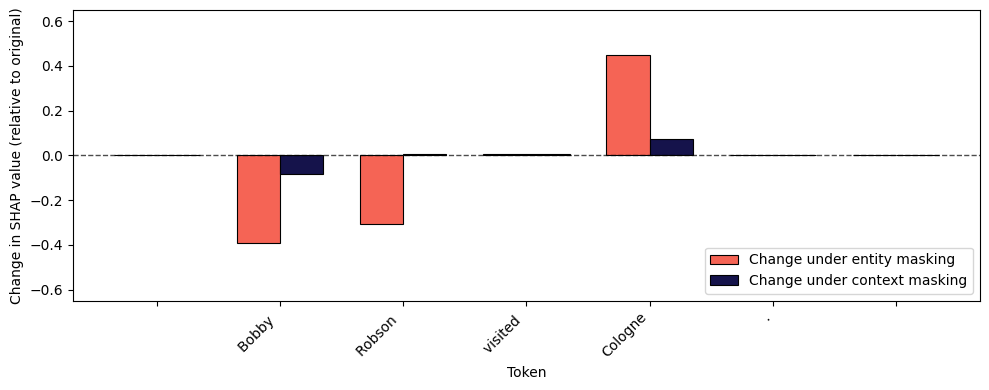


Example: Ambiguous PER/LOC (Jordan)
Target class for SHAP: LOC | original probs: {'PER': np.float64(0.0), 'ORG': np.float64(0.0), 'LOC': np.float64(1.0), 'MISC': np.float64(0.0)}


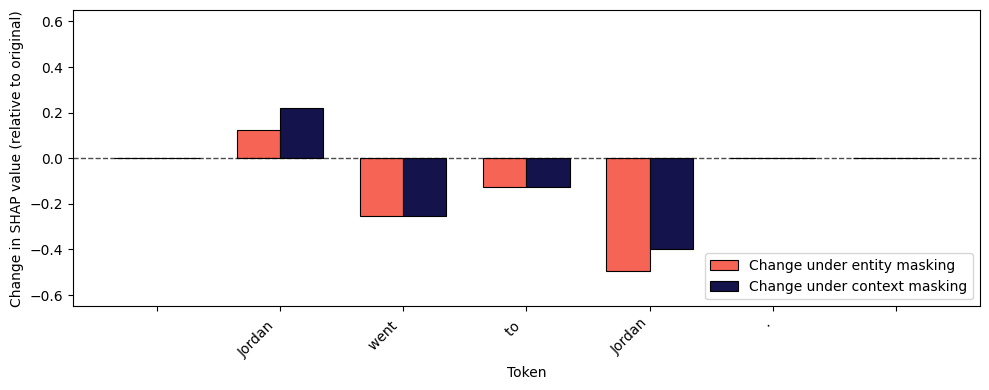


Example: Ambiguous ORG/LOC (Apple / Apple Valley)
Target class for SHAP: ORG | original probs: {'PER': np.float64(0.0), 'ORG': np.float64(0.5000968353445007), 'LOC': np.float64(0.4999031646554994), 'MISC': np.float64(0.0)}


  0%|          | 0/90 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

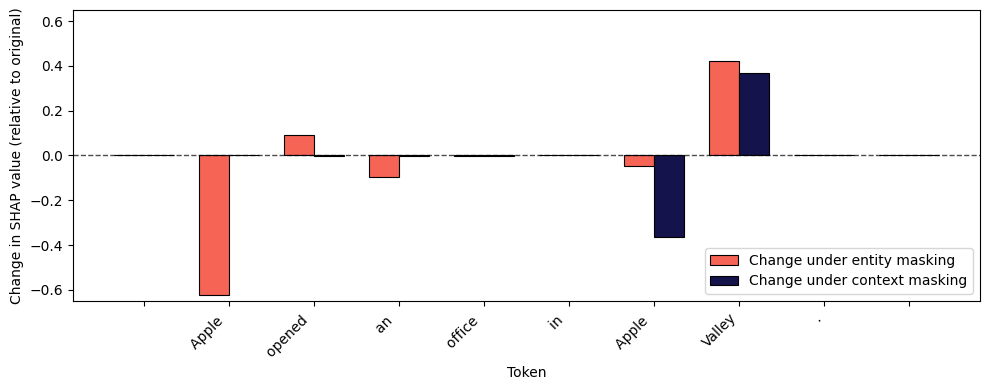

In [15]:
for ex in examples:
    tokens_shap, shap_vals = get_shap_for_variants(ex, target_class="auto")
    
    orig_probs = predict_proba([detokenize(ex["tokens"])])[0]
    target_idx = int(np.argmax(orig_probs))
    target_name = class_names[target_idx]
    
    plot_delta_attributions(tokens_shap, shap_vals)


In [16]:
from lime.lime_text import LimeTextExplainer
import numpy as np

lime_explainer = LimeTextExplainer(class_names=class_names)

def run_lime(text, target_idx, num_features=10):
    exp = lime_explainer.explain_instance(
        text_instance=text,
        classifier_fn=predict_proba,
        labels=[target_idx],
        num_features=num_features
    )
    return exp.as_list(label=target_idx)


In [17]:
for ex in examples:
    tokens = ex["tokens"]
    bio = ex["bio_tags"]
    
    texts = {
        "original": detokenize(tokens),
        "entity_masked": mask_tokens(tokens, bio, mode="entity"),
        "context_masked": mask_tokens(tokens, bio, mode="context"),
    }
    
    # target class from ORIGINAL
    probs = predict_proba([texts["original"]])[0]
    target_idx = int(np.argmax(probs))
    target_name = class_names[target_idx]
    
    print("\n" + "="*80)
    print(f"LIME explanations — {ex['name']} (target class: {target_name})")
    print("="*80)
    
    for variant, text in texts.items():
        print(f"\n--- {variant} ---")
        print("Text:", text)
        lime_weights = run_lime(text, target_idx)
        for tok, weight in lime_weights:
            print(f"{tok:15s} {weight:+.4f}")



LIME explanations — PER + LOC (clear) (target class: PER)

--- original ---
Text: Bobby Robson visited Cologne.
Bobby           +0.2884
Robson          +0.2865
Cologne         -0.2425
visited         -0.2395

--- entity_masked ---
Text: [MASK] [MASK] visited [MASK] .
MASK            +0.0000
visited         +0.0000

--- context_masked ---
Text: Bobby Robson [MASK] Cologne [MASK]
Cologne         -0.4316
Bobby           +0.1996
Robson          +0.1948
MASK            +0.0278

LIME explanations — Ambiguous PER/LOC (Jordan) (target class: LOC)

--- original ---
Text: Jordan went to Jordan.
Jordan          +0.9099
went            +0.4063
to              +0.4063

--- entity_masked ---
Text: [MASK] went to [MASK] .
MASK            +0.0000
went            +0.0000
to              +0.0000

--- context_masked ---
Text: Jordan [MASK] [MASK] Jordan [MASK]
MASK            +0.1790
Jordan          -0.0706

LIME explanations — Ambiguous ORG/LOC (Apple / Apple Valley) (target class: ORG)

--- original -